In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# STEP 1: GIVEN VECTORS
# Vector 2 is longer and slightly stretched compared to Vector 1.
# DTW is needed because simple point-to-point comparison will fail due to length differences.
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])


In [3]:
# Time axes
t1 = np.arange(len(vector1))
t2 = np.arange(len(vector2))

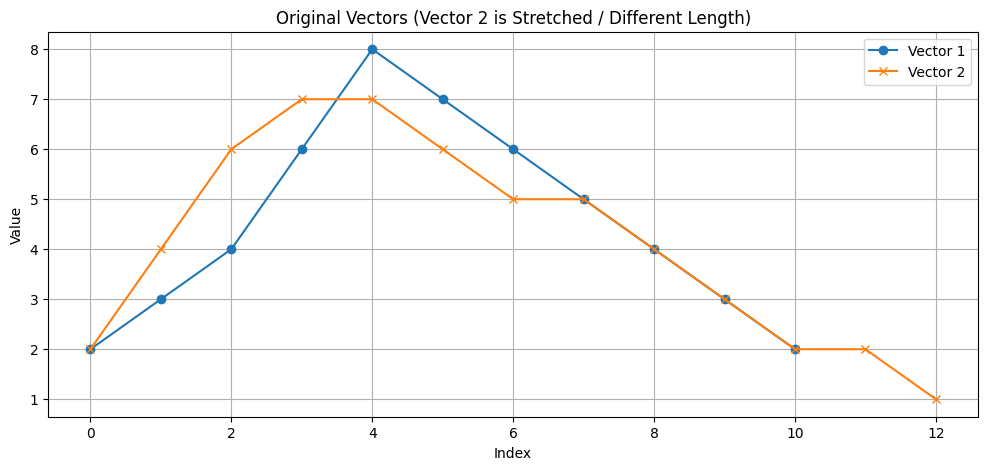

In [4]:
# STEP 2: PLOT THE ORIGINAL VECTORS
# The plot clearly shows Vector 2 is stretched and has a slower pattern.
# DTW allows us to align them even with this time distortion.
plt.figure(figsize=(12,5))
plt.plot(t1, vector1, marker='o', label='Vector 1')
plt.plot(t2, vector2, marker='x', label='Vector 2')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Original Vectors (Vector 2 is Stretched / Different Length)")
plt.grid(True)
plt.legend()
plt.show()


In [5]:
# STEP 3: DYNAMIC TIME WARPING IMPLEMENTATION
n = len(vector1)
m = len(vector2)

# Create cost matrix filled with infinity
cost_matrix = np.full((n+1, m+1), np.inf)
cost_matrix[0, 0] = 0

# Compute accumulated cost matrix
# Each cell in the cost matrix represents the minimum cumulative cost
# to align vector1[0:i] with vector2[0:j].
# This matrix captures stretching or compression needed for alignment.
for i in range(1, n+1):
    for j in range(1, m+1):
        cost = abs(vector1[i-1] - vector2[j-1])  # local cost
        cost_matrix[i, j] = cost + min(
            cost_matrix[i-1, j],     # insertion (stretch vector1)
            cost_matrix[i, j-1],     # deletion (stretch vector2)
            cost_matrix[i-1, j-1]    # match (best alignment)
        )

dtw_distance = cost_matrix[n, m]
print("DTW Distance:", dtw_distance)
# The DTW distance quantifies similarity.
# Smaller distance = higher similarity. DTW distance includes warping cost.


DTW Distance: 3.0


In [6]:
# STEP 4: TRACEBACK TO FIND OPTIMAL WARPING PATH
# Traceback finds the optimal path that shows how each element in Vector 1
# is matched to one or more elements in Vector 2 (non-linear mapping).
i, j = n, m
path = []

while i > 0 and j > 0:
    path.append((i-1, j-1))
    min_prev = min(
        cost_matrix[i-1, j], 
        cost_matrix[i, j-1], 
        cost_matrix[i-1, j-1]
    )
    if min_prev == cost_matrix[i-1, j]:
        i -= 1
    elif min_prev == cost_matrix[i, j-1]:
        j -= 1
    else:
        i -= 1
        j -= 1

path.reverse()

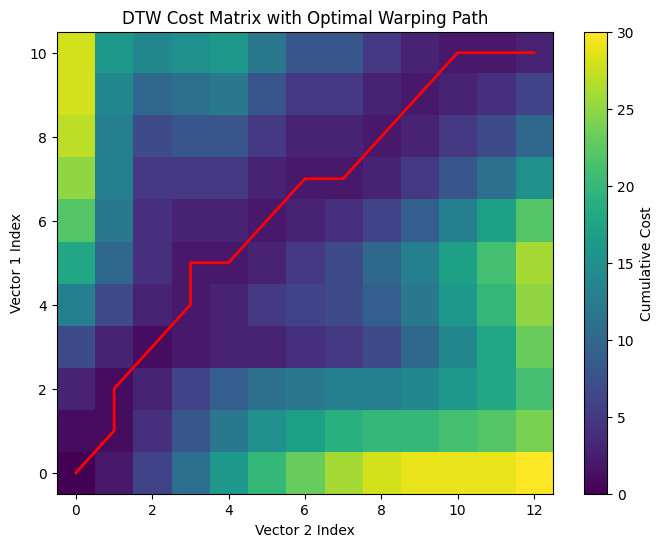

In [7]:
# STEP 5: VISUALIZE COST MATRIX + WARPING PATH
# The warping path on the cost matrix shows how DTW matches the two sequences.
# A diagonal-heavy path indicates similar shape; horizontal/vertical segments show stretching.
plt.figure(figsize=(8, 6))
plt.imshow(cost_matrix[1:, 1:], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label="Cumulative Cost")
plt.title("DTW Cost Matrix with Optimal Warping Path")

# Plot the path
path_x = [p[1] for p in path]
path_y = [p[0] for p in path]
plt.plot(path_x, path_y, 'r-', linewidth=2)

plt.xlabel("Vector 2 Index")
plt.ylabel("Vector 1 Index")
plt.show()


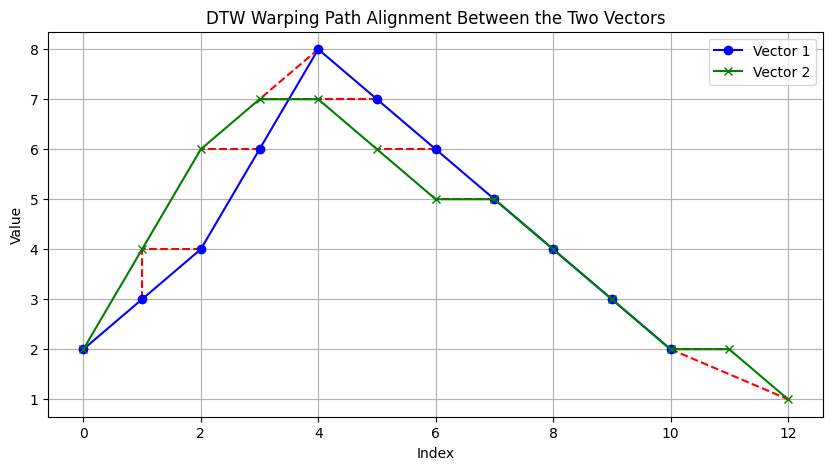

In [9]:
# STEP 6: TIME ALIGNMENT PATH PLOT
# The red dashed lines show which elements are matched.
# Non-linear mapping proves that DTW can align sequences with shifting/stretching.
plt.figure(figsize=(10,5))
for (i, j) in path:
    plt.plot([i, j], [vector1[i], vector2[j]], 'r--')

plt.plot(vector1, 'bo-', label="Vector 1")
plt.plot(vector2, 'gx-', label="Vector 2")
plt.title("DTW Warping Path Alignment Between the Two Vectors")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# DTW successfully aligned the two vectors even though they differ in length and timing.
# The warping path demonstrates non-linear alignment, allowing many-to-one or one-to-many matches.
# This is something simple linear normalization cannot do.
# The DTW distance gives a numerical measure of similarity — smaller distance means more similarity.V